# Evaluierung & Analyse des Loss-Aggregations-Experiments (Sum vs. Mean DPO)
### Masterarbeit: Automatische Übersetzung von Alltagssprache (AS) in Leichte Sprache (LS)

Dieses Notebook analysiert und vergleicht den Einfluss der **Sequenz-Wahrscheinlichkeits-Aggregation** im Direct Preference Optimization (DPO) Training auf das Encoder-Decoder-Modell (`facebook/mbart-large-50`):

1. **Klassische Summierung (`sum`):** $\log \pi(y \mid x) = \sum_{t=1}^T \log \pi(y_t \mid x, y_{<t})$
   * *Hypothese:* Akkumuliert negative Log-Wahrscheinlichkeiten proportional zur Textlänge. Das Modell lernt eine Kürzungsstrategie (Degeneration auf kurze Satzfragmente).
2. **Längen-normalisierter Mittelwert (`mean`):** $\overline{\log \pi(y \mid x)} = \frac{1}{T} \sum_{t=1}^T \log \pi(y_t \mid x, y_{<t})$
   * *Hypothese:* Eliminiert den Längen-Bias und bewertet die durchschnittliche Modellzuversicht pro generiertem Token, wodurch vollständige Leichte-Sprache-Sätze erhalten bleiben.

### Untersuchte Modellvarianten:
- **SFT Baseline:** Supervised Fine-Tuning Referenz (`results/models/sft`)
- **DPO Sum (Classic):** DPO-Training mit summierten Log-Likelihoods (`results/models/loss_aggregation_exp/dpo_sum`)
- **DPO Mean (Length-Normalized):** DPO-Training mit gemittelten Log-Likelihoods (`results/models/loss_aggregation_exp/dpo_mean`)

In [1]:
# ==============================================================================
# 1. SYSTEM-SETUP & IMPORTE
# ==============================================================================
import os
import sys
import json
import glob
import random
from collections import Counter
from typing import List, Dict, Any, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm


# Arbeitsverzeichnis robust auf Projekt-Root setzen
while not (os.path.exists(".git") or os.path.exists("data")) and os.path.dirname(os.getcwd()) != os.getcwd():
    os.chdir("..")

if not os.path.exists("data"):
        if os.path.exists(candidate):
            os.chdir(candidate)

print("Arbeitsverzeichnis:", os.getcwd())
print(f"Nutze Device: {DEVICE}")

# Seaborn & Plot Style
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["figure.dpi"] = 150

Arbeitsverzeichnis: /home/fiete/master-thesis
Nutze Device: cuda


## 1. Loss-Aggregations-Ergebnisse laden

In [3]:
# ==============================================================================
# 1. ERGEBNIS-DATEN EINLESEN (Loss-Aggregation Experiment)
# ==============================================================================
CSV_PATH = "results/evaluation/loss_aggregation_comparison_summary.csv"
if not os.path.exists(CSV_PATH):
    CSV_PATH = "../../../results/evaluation/loss_aggregation_comparison_summary.csv"

df_summary = pd.read_csv(CSV_PATH)
print(f"Ergebnisse erfolgreich geladen: {len(df_summary)} Zeilen aus {CSV_PATH}")
display(df_summary)


## 2. Quantitative Vergleichstabelle

In [6]:
# ==============================================================================
# 6. TABELLARISCHE AUSWERTUNG
# ==============================================================================
if 'df_summary' in locals() and len(df_summary) > 0:
    styled_df = df_summary.copy()
    for col in styled_df.columns:
        if col != "Modell" and col != "model_name":
            styled_df[col] = styled_df[col].apply(lambda x: f"{x:.4f}" if isinstance(x, (float, int, np.floating)) else x)
    display(styled_df)
    
    print("\n=== Markdown-Tabelle fuer die Masterarbeit ===\n")
    try:
        print(styled_df.to_markdown(index=False))
    except Exception:
        cols = [str(c) for c in styled_df.columns]
        header = "| " + " | ".join(cols) + " |"
        sep = "| " + " | ".join(["---"] * len(cols)) + " |"
        rows = ["| " + " | ".join([str(val) for val in row]) + " |" for row in styled_df.values]
        print("\n".join([header, sep] + rows))
else:
    print("Keine Zusammenfassungstabelle verfuegbar.")

,Modell,Ø Simplicity ($R_{style}$),Ø Semantik zu AS ($R_{sem}$),Ø Treue zu LS ($Sim_{ref}$),Composite Reward,BLEU,ROUGE-L F1,Ø Gen. Tokens,Kompressionsrate,Truncation Rate (%)
0,SFT Baseline,0.6734,0.8528,0.8476,0.7631,0.0057,0.1260,165.3784,0.3900,78.3784
1,DPO Sum (Classic),0.6616,0.8590,0.8520,0.7603,0.0090,0.1267,162.8108,0.3874,72.9730
2,DPO Mean (Length-Normalized),0.6938,0.8595,0.8566,0.7767,0.0080,0.1228,161.7297,0.3827,67.5676



=== Markdown-Tabelle fuer die Masterarbeit ===

| Modell                       |   Ø Simplicity ($R_{style}$) |   Ø Semantik zu AS ($R_{sem}$) |   Ø Treue zu LS ($Sim_{ref}$) |   Composite Reward |   BLEU |   ROUGE-L F1 |   Ø Gen. Tokens |   Kompressionsrate |   Truncation Rate (%) |
|:-----------------------------|-----------------------------:|-------------------------------:|------------------------------:|-------------------:|-------:|-------------:|----------------:|-------------------:|----------------------:|
| SFT Baseline                 |                       0.6734 |                         0.8528 |                        0.8476 |             0.7631 | 0.0057 |       0.126  |         165.378 |             0.39   |               78.3784 |
| DPO Sum (Classic)            |                       0.6616 |                         0.859  |                        0.852  |             0.7603 | 0.009  |       0.1267 |         162.811 |             0.3874 |               72.973  |
| D

## 3. Visualisierungen: Textlänge, Truncation & Trade-Off

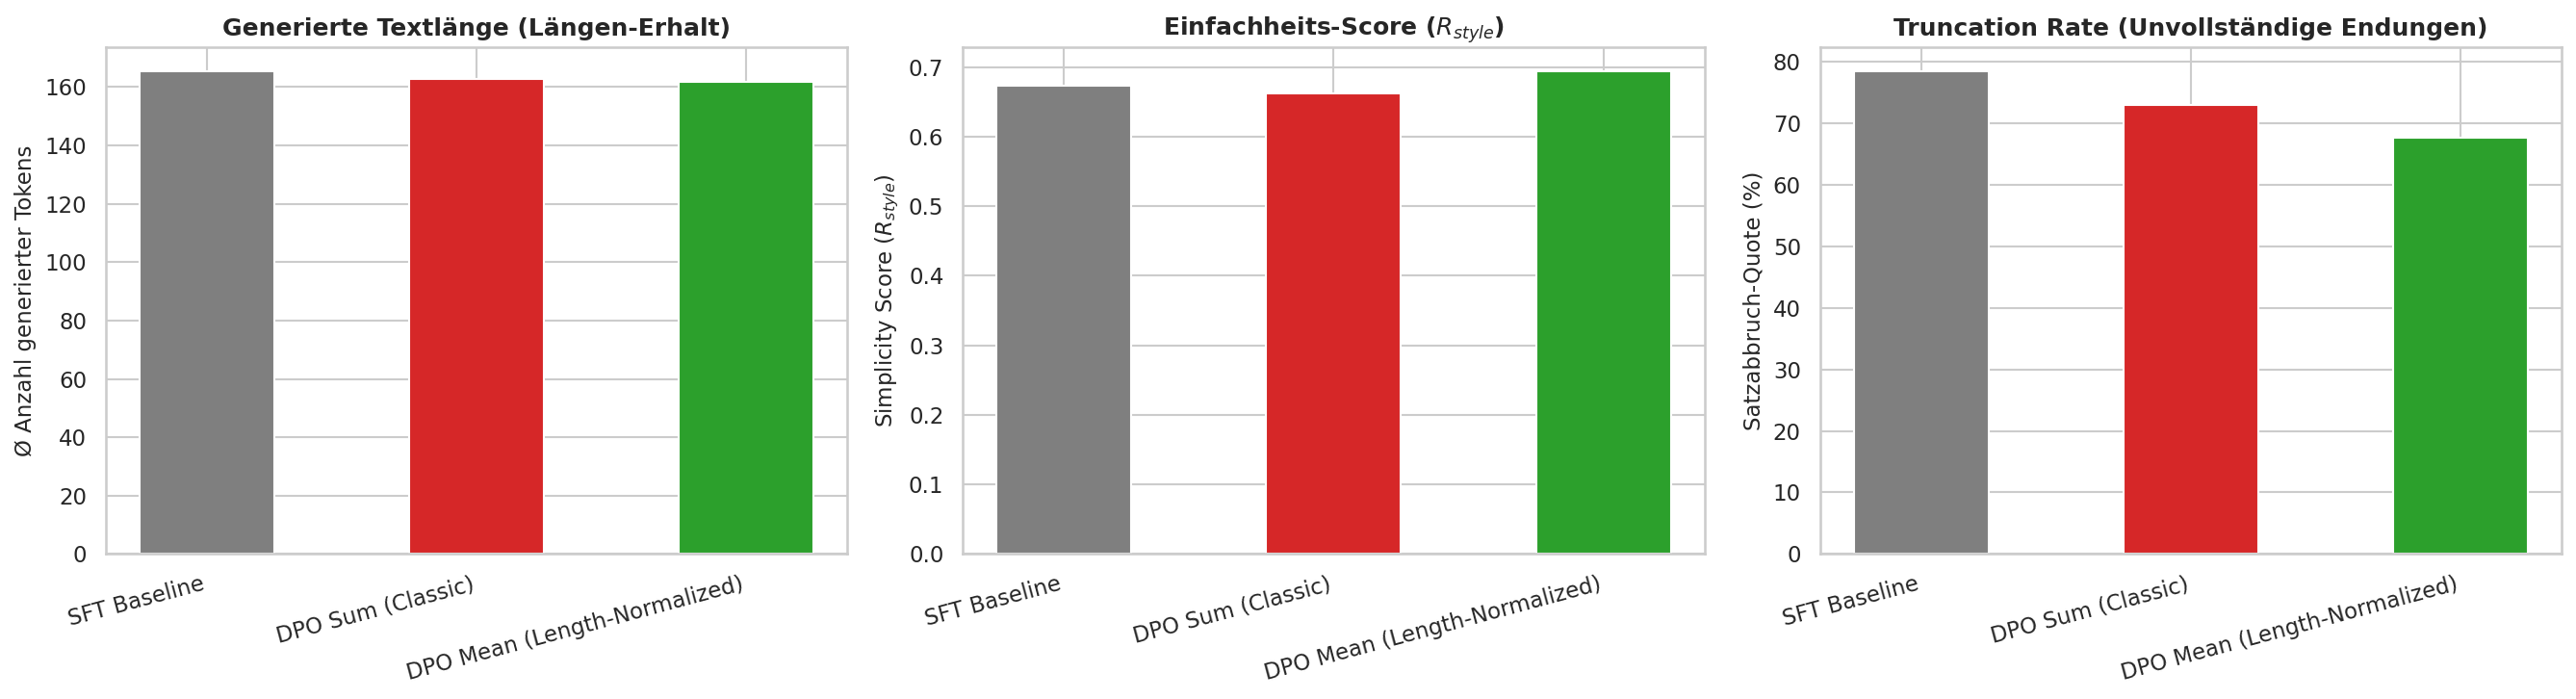

In [7]:
# ==============================================================================
# 7. KERNVERGLEICH: TOKEN-LAENGE & TRUNCATION RATE (SUM VS. MEAN)
# ==============================================================================
if 'df_summary' in locals() and len(df_summary) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    name_col = [c for c in df_summary.columns if "Modell" in c or "model" in c][0]
    models = df_summary[name_col]
    x = np.arange(len(models))
    
    # 1. Generierte Token-Länge
    tok_col = [c for c in df_summary.columns if "Tokens" in c or "avg_gen_tokens" in c][0]
    axes[0].bar(x, df_summary[tok_col].astype(float), color=["#7f7f7f", "#d62728", "#2ca02c"], width=0.5)
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(models, rotation=15, ha="right")
    axes[0].set_ylabel("Ø Anzahl generierter Tokens", fontsize=11)
    axes[0].set_title("Generierte Textlänge (Längen-Erhalt)", fontsize=12, fontweight="bold")
    
    # 2. Simplicity Score
    simp_col = [c for c in df_summary.columns if "Simplicity" in c or "r_style" in c][0]
    axes[1].bar(x, df_summary[simp_col].astype(float), color=["#7f7f7f", "#d62728", "#2ca02c"], width=0.5)
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(models, rotation=15, ha="right")
    axes[1].set_ylabel("Simplicity Score ($R_{style}$)", fontsize=11)
    axes[1].set_title("Einfachheits-Score ($R_{style}$)", fontsize=12, fontweight="bold")
    
    # 3. Truncation Rate (%)
    trunc_col = [c for c in df_summary.columns if "Truncation" in c or "truncation" in c][0]
    axes[2].bar(x, df_summary[trunc_col].astype(float), color=["#7f7f7f", "#d62728", "#2ca02c"], width=0.5)
    axes[2].set_xticks(x)
    axes[2].set_xticklabels(models, rotation=15, ha="right")
    axes[2].set_ylabel("Satzabbruch-Quote (%)", fontsize=11)
    axes[2].set_title("Truncation Rate (Unvollständige Endungen)", fontsize=12, fontweight="bold")
    
    plt.tight_layout()
    plt.savefig("results/plots/loss_aggregation_length_comparison.png", dpi=300)
    plt.show()
else:
    print("Keine Zusammenfassungsdaten fuer Plots vorhanden.")

## 4. Qualitativer Side-by-Side Modellvergleich (Beispielsätze)

In [8]:
# ==============================================================================
# 8. QUALITATIVES AUDIT: STICHPROBEN IM DETAIL
# ==============================================================================
if 'df_details' in locals() and len(df_details) > 0:
    sample_queries = df_details["as_text"].unique()[:4]
    
    for idx, as_s in enumerate(sample_queries, 1):
        sub_df = df_details[df_details["as_text"] == as_s]
        ls_ref = sub_df["ls_ref_text"].iloc[0]
        
        print(f"\n{'#'*90}")
        print(f"BEISPIEL {idx}:")
        print(f"[AS Quelle] : {as_s}")
        print(f"[LS Referenz]: {ls_ref}")
        print(f"{'-'*90}")
        
        for _, r in sub_df.iterrows():
            print(f"[{r['model_name']:30s}] (Simp: {r['r_style']:.3f} | Sem-AS: {r['r_sem_as']:.3f} | Tokens: {r['gen_tokens']}):")
            print(f"  {r['generated_text']}\n")
else:
    print("Keine Detail-Uebersetzungen verfuegbar.")


##########################################################################################
BEISPIEL 1:
[AS Quelle] : Kiel, 15.10.2020. Arbeit zweiter oder dritter Klasse?? - Positionspapier Die Rede ist in diesemFall von der Entlohnung für Menschen, die in einer Werkstatt (WfbM) arbeiten. Wichtiges Detail: Es sind die Werkstätten selbst, die diese Veränderung dringend fordern. Der Lohn der Mitarbeiter*innen mit Werkstattvertrag ist bei einem 6 – 8 Stunden Arbeitstag weit davon entfernt, auf dieser Basis ein selbstfinanziertes Leben führen zu können. Das bedeutet, dass die Menschen grundsätzlich Grundsicherung beantragen müssen, um ihren Lebensunterhalt zu bestreiten – es sei denn, sie erhalten bereits eine Erwerbsminderungsrente und können in der Werkstatt noch so viel dazu verdienen, dass es gerade zum Leben reicht. Die Pandemie-bedingten Betretungsverbote für die WfbMs und die damit aller Orten eingebrochenen Erträge machen die Auszahlung dieser Löhne nun aber auch immer schwieriger